In [2]:
#Libaries
from sentence_transformers import SentenceTransformer
from sentence_transformers import CrossEncoder
from sentence_transformers import SparseEncoder
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import time

Model from: https://www.sbert.net/.
In this source code i test 3 different type with SBERT.

*   Embedding Model
*   Reranker Model
*   Sqarse Encoder Model

In [20]:
# 1. Load a pretrained Sentence Transformer model
model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

# The sentences to encode
sentences = [
    "The weather is lovely today.",
    "It's so sunny outside!",
    "He drove to the stadium.",
]

# 2. Calculate embeddings by calling model.encode()
embeddings = model.encode(sentences)
print("Kích thước ma trận/vector embedding do model tạo ra", embeddings.shape)
# [3, 384]

# 3. Calculate the embedding similarities
similarities = model.similarity(embeddings, embeddings)
print("Độ tương đồng:\n", similarities)
#           Câu 1    Câu 2    Câu 3
#Câu 1      1.000    0.666    0.105
#Câu 2      0.666    1.000    0.141
#Câu 3      0.105    0.141    1.000

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Kích thước ma trận/vector embedding do model tạo ra (3, 384)
Độ tương đồng:
 tensor([[1.0000, 0.6660, 0.1046],
        [0.6660, 1.0000, 0.1411],
        [0.1046, 0.1411, 1.0000]])


In [ ]:
# 1. Load a pretrained CrossEncoder model
model = CrossEncoder("cross-encoder/ms-marco-MiniLM-L6-v2")

# The texts for which to predict similarity scores
query = "How many people live in Berlin?"
passages = [
    "Berlin had a population of 3,520,031 registered inhabitants in an area of 891.82 square kilometers.",
    "Berlin has a yearly total of about 135 million day visitors, making it one of the most-visited cities in the European Union.",
    "In 2013 around 600,000 Berliners were registered in one of the more than 2,300 sport and fitness clubs.",
]

# 2a. Either predict scores pairs of texts
scores = model.predict([(query, passage) for passage in passages])
print(scores)
# => [8.607139 5.506266 6.352977]

# 2b. Or rank a list of passages for a query
ranks = model.rank(query, passages, return_documents=True)

print("Query:", query)
for rank in ranks:
    print(f"- #{rank['corpus_id']} ({rank['score']:.2f}): {rank['text']}")

"""
Query: How many people live in Berlin?
- #0 (8.61): Berlin had a population of 3,520,031 registered inhabitants in an area of 891.82 square kilometers.
- #2 (6.35): In 2013 around 600,000 Berliners were registered in one of the more than 2,300 sport and fitness clubs.
- #1 (5.51): Berlin has a yearly total of about 135 million day visitors, making it one of the most-visited cities in the European Union.
"""

config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 90.9MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/1.33k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

[8.60714   5.5062666 6.3529835]
Query: How many people live in Berlin?
- #0 (8.61): Berlin had a population of 3,520,031 registered inhabitants in an area of 891.82 square kilometers.
- #2 (6.35): In 2013 around 600,000 Berliners were registered in one of the more than 2,300 sport and fitness clubs.
- #1 (5.51): Berlin has a yearly total of about 135 million day visitors, making it one of the most-visited cities in the European Union.


'\nQuery: How many people live in Berlin?\n- #0 (8.61): Berlin had a population of 3,520,031 registered inhabitants in an area of 891.82 square kilometers.\n- #2 (6.35): In 2013 around 600,000 Berliners were registered in one of the more than 2,300 sport and fitness clubs.\n- #1 (5.51): Berlin has a yearly total of about 135 million day visitors, making it one of the most-visited cities in the European Union.\n'

In [ ]:
# 1. Load a pretrained SparseEncoder model
model = SparseEncoder("naver/splade-cocondenser-ensembledistil")

# The sentences to encode
sentences = [
    "The weather is lovely today.",
    "It's so sunny outside!",
    "He drove to the stadium.",
]

# 2. Calculate sparse embeddings by calling model.encode()
embeddings = model.encode(sentences)
print(embeddings.shape)
# [3, 30522] - sparse representation with vocabulary size dimensions

# 3. Calculate the embedding similarities
similarities = model.similarity(embeddings, embeddings)
print(similarities)
# tensor([[   35.629,     9.154,     0.098],
#         [    9.154,    27.478,     0.019],
#         [    0.098,     0.019,    29.553]])

# 4. Check sparsity stats
stats = SparseEncoder.sparsity(embeddings)
print(f"Sparsity: {stats['sparsity_ratio']:.2%}")
# Sparsity: 99.84%

modules.json:   0%|          | 0.00/274 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/274 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.93k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/670 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

torch.Size([3, 30522])
tensor([[3.5629e+01, 9.1541e+00, 9.8058e-02],
        [9.1541e+00, 2.7478e+01, 1.9061e-02],
        [9.8058e-02, 1.9061e-02, 2.9553e+01]])
Sparsity: 99.84%


In [16]:
df = pd.read_csv("dataset_10000_outfit.csv")
df = df.head(1000)


class Evaluator:

    def __init__(self, model_name):
        self.model_name = model_name
        self.model = SentenceTransformer(model_name)

    def predict(self, sentence1, sentence2):

        embedding1 = self.model.encode(sentence1)
        embedding2 = self.model.encode(sentence2)

        return cosine_similarity(
            [embedding1],
            [embedding2]
        )[0][0]

    def evaluate_df(self, df):

        start_time = time.perf_counter()

        embedding1 = self.model.encode(
            df["sentence1"].tolist()
        )

        embedding2 = self.model.encode(
            df["sentence2"].tolist()
        )

        similarity = cosine_similarity(
            embedding1,
            embedding2
        ).diagonal()

        end_time = time.perf_counter()

        res = df.copy()
        res["similarity"] = similarity

        return res, end_time - start_time

    def line_chart(self, res, group_size=100):

        grouped = (
            res["similarity"]
            .groupby(res.index // group_size)
            .mean()
        )

        plt.figure(figsize=(12, 6))

        plt.plot(
            grouped.index + 1,
            grouped.values
        )

        plt.xlabel(f"Group ({group_size} pairs)")
        plt.ylabel("Average Similarity")
        plt.title("Average Similarity per Group")

        plt.ylim(0, 1)
        plt.grid(True)

        plt.tight_layout()
        plt.show()

    @staticmethod
    def compare_line_chart(df, models, group_size=100):

        plt.figure(figsize=(12, 6))

        for model_name in models:

            evaluator = Evaluator(model_name)

            res, runtime = evaluator.evaluate_df(df)

            grouped = (
                res["similarity"]
                .groupby(res.index // group_size)
                .mean()
            )

            plt.plot(
                grouped.index + 1,
                grouped.values,
                label=model_name.split("/")[-1]
            )

        plt.xlabel(f"Group ({group_size} sentence pairs)")
        plt.ylabel("Average Cosine Similarity")
        plt.title("SBERT Model Comparison")

        plt.ylim(0, 1)

        plt.grid(True)
        plt.legend()

        plt.tight_layout()
        plt.show()

    @staticmethod
    def compare_performance(df, models):

        results = []

        for model_name in models:

            evaluator = Evaluator(model_name)

            res, runtime = evaluator.evaluate_df(df)

            results.append({
                "Model": model_name.split("/")[-1],
                "Average Similarity": res["similarity"].mean(),
                "Min Similarity": res["similarity"].min(),
                "Max Similarity": res["similarity"].max(),
                "Inference Time (s)": runtime
            })

        return pd.DataFrame(results)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

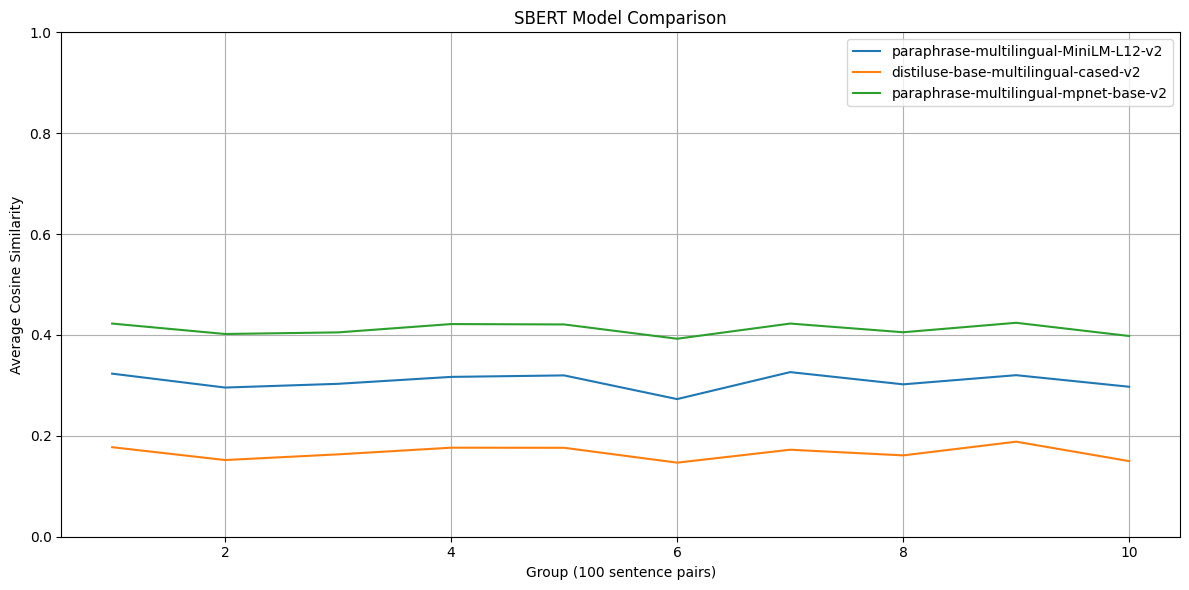

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

                                Model  Average Similarity  Min Similarity  Max Similarity  Inference Time (s)
paraphrase-multilingual-MiniLM-L12-v2            0.307787       -0.014777        0.689636           15.285191
 distiluse-base-multilingual-cased-v2            0.166458        0.004007        0.591673           31.415896
paraphrase-multilingual-mpnet-base-v2            0.411473        0.124051        0.783242           56.601469


In [17]:
models = [
    "paraphrase-multilingual-MiniLM-L12-v2",
    "distiluse-base-multilingual-cased-v2",
    "paraphrase-multilingual-mpnet-base-v2"
]

Evaluator.compare_line_chart(df, models)

performance = Evaluator.compare_performance(
    df, models, group_size=100
)

print(performance.to_string(index=False))